In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import json
import pickle
import numpy as np
import cv2
from tqdm import tqdm
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models.detection.mask_rcnn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ── Dataset paths ──────────────────────────────────────────────────────────────
DATA_ROOT = "/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2"

train_img_folder = DATA_ROOT + "/train/image"
val_img_folder   = DATA_ROOT + "/validation/image"
train_json_folder = DATA_ROOT + "/train/annos"
val_json_folder   = DATA_ROOT + "/validation/annos"

# ── Pre-processed path lists (image paths only) ────────────────────────────────
TRAIN_PKL = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed/train_data.pkl"
VAL_PKL   = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed-val/validation_data.pkl"

# ── Output ─────────────────────────────────────────────────────────────────────
SAVE_PATH = "/kaggle/working/best_maskrcnn.pth"

In [3]:
with open(TRAIN_PKL, "rb") as f:
    train_paths, _ = pickle.load(f)

with open(VAL_PKL, "rb") as f:
    val_paths, _ = pickle.load(f)

print(f"Total train images: {len(train_paths)}")
print(f"Total val images  : {len(val_paths)}")
print("Sample train path :", train_paths[0])

Total train images: 144174
Total val images  : 23741
Sample train path : /kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2/train/image/039350.jpg


In [4]:
# Top-5 most frequent categories in DeepFashion2
# 1=short sleeve top, 2=long sleeve top, 7=shorts, 8=trousers, 9=skirt
top5_ids = [1, 8, 7, 2, 9]

category_to_index = {cat: i for i, cat in enumerate(top5_ids)}

# Human-readable names aligned to model label indices 1..5  (0 = background)
IDX_TO_NAME = {
    0: "background",
    1: "short_sleeve_top",
    2: "trousers",
    3: "shorts",
    4: "long_sleeve_top",
    5: "skirt",
}

NUM_CLASSES = 6   # 5 clothing + 1 background
print("category_to_index:", category_to_index)
print("idx_to_name      :", IDX_TO_NAME)

category_to_index: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
idx_to_name      : {0: 'background', 1: 'short_sleeve_top', 2: 'trousers', 3: 'shorts', 4: 'long_sleeve_top', 5: 'skirt'}


In [5]:
def parse_annotation(json_path):
    """
    Parse a DeepFashion2 JSON annotation file.
    Returns boxes, labels (1-indexed for Mask R-CNN), and raw polygon segmentations.
    """
    with open(json_path) as f:
        data = json.load(f)

    boxes, labels, masks = [], [], []

    for key in data:
        if not key.startswith("item"):
            continue

        cid = data[key]["category_id"]
        if cid not in category_to_index:
            continue

        x1, y1, x2, y2 = data[key]["bounding_box"]

        # Skip degenerate boxes
        if x2 <= x1 or y2 <= y1:
            continue

        seg = data[key]["segmentation"]

        boxes.append([x1, y1, x2, y2])
        labels.append(category_to_index[cid] + 1)   # +1 because 0 is background
        masks.append(seg)

    return boxes, labels, masks

In [6]:
def polygons_to_mask(polygons, height, width):
    """
    Convert a list of polygon coordinate lists into a binary uint8 mask.
    Each polygon is [x1, y1, x2, y2, ...] flattened.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

In [7]:
class DetectionDataset(Dataset):
    """
    PyTorch Dataset for Mask R-CNN on DeepFashion2.
    Returns (image_tensor, target_dict) pairs.
    """

    def __init__(self, image_paths, json_folder):
        self.image_paths = image_paths
        self.json_folder  = json_folder

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        image     = Image.open(img_path).convert("RGB")

        json_name = os.path.basename(img_path).replace(".jpg", ".json")
        json_path = os.path.join(self.json_folder, json_name)

        boxes, labels, segmentations = parse_annotation(json_path)

        # Skip images with no valid annotations
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.image_paths))

        width, height = image.size

        # Convert polygon segmentations to binary masks
        masks = []
        for seg in segmentations:
            mask = polygons_to_mask(seg, height, width)
            masks.append(mask)

        masks = torch.tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes" : torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "masks" : masks,
        }

        return F.to_tensor(image), target


def collate_fn(batch):
    return tuple(zip(*batch))

In [8]:
# Adjust subset sizes based on available compute
TRAIN_SIZE = 5000
VAL_SIZE   = 2000
BATCH_SIZE = 4

train_dataset = DetectionDataset(train_paths[:TRAIN_SIZE], train_json_folder)
val_dataset   = DetectionDataset(val_paths[:VAL_SIZE],   val_json_folder)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 1250
Val   batches: 500


In [ ]:
# ── Load pretrained backbone ───────────────────────────────────────────────────
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.COCO_V1
)

# ── Replace box predictor ──────────────────────────────────────────────────────
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, NUM_CLASSES
    )

# ── Replace mask predictor ─────────────────────────────────────────────────────
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask,
        256,           # hidden dimension
        NUM_CLASSES
    )

model = model.to(device)
print("Model ready on", device)

From scratch -


In [9]:
# ── Train from scratch (randomly initialized weights) ─────────────────────────
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

# ── Replace box predictor ──────────────────────────────────────────────────────
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, NUM_CLASSES
    )

# ── Replace mask predictor ─────────────────────────────────────────────────────
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask,
        256,
        NUM_CLASSES
    )

model = model.to(device)
print("Model ready (from scratch) on", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


Model ready (from scratch) on cuda


In [11]:
EPOCHS = 10
best_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Training phase ─────────────────────────────────────────────────────────
    model.train()
    total_loss      = 0
    total_cls_loss  = 0
    total_box_loss  = 0
    total_mask_loss = 0
    total_obj_loss  = 0
    total_rpn_loss  = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):

        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss      += loss.item()
        total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
        total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
        total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
        total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
        total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    n = len(train_loader)
    avg_loss      = total_loss      / n
    avg_cls_loss  = total_cls_loss  / n
    avg_box_loss  = total_box_loss  / n
    avg_mask_loss = total_mask_loss / n
    avg_obj_loss  = total_obj_loss  / n
    avg_rpn_loss  = total_rpn_loss  / n

    # ── Validation phase ────────────────────────────────────────────────────────
    model.train()   # Mask R-CNN needs train() mode to compute losses on val too
    val_total_loss      = 0
    val_total_cls_loss  = 0
    val_total_box_loss  = 0
    val_total_mask_loss = 0
    val_total_obj_loss  = 0
    val_total_rpn_loss  = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):

            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            val_total_loss      += sum(loss_dict.values()).item()
            val_total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
            val_total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
            val_total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
            val_total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
            val_total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    m = len(val_loader)
    val_avg_loss      = val_total_loss      / m
    val_avg_cls_loss  = val_total_cls_loss  / m
    val_avg_box_loss  = val_total_box_loss  / m
    val_avg_mask_loss = val_total_mask_loss / m
    val_avg_obj_loss  = val_total_obj_loss  / m
    val_avg_rpn_loss  = val_total_rpn_loss  / m

    # ── Print comparison ────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*65}")
    print(f"{'Loss':<25} {'Train':>10} {'Val':>10} {'Diff':>10}")
    print(f"{'-'*65}")
    print(f"{'Total Loss':<25} {avg_loss:>10.4f} {val_avg_loss:>10.4f} {val_avg_loss - avg_loss:>+10.4f}")
    print(f"{'Classifier Loss':<25} {avg_cls_loss:>10.4f} {val_avg_cls_loss:>10.4f} {val_avg_cls_loss - avg_cls_loss:>+10.4f}")
    print(f"{'Box Reg Loss':<25} {avg_box_loss:>10.4f} {val_avg_box_loss:>10.4f} {val_avg_box_loss - avg_box_loss:>+10.4f}")
    print(f"{'Mask Loss':<25} {avg_mask_loss:>10.4f} {val_avg_mask_loss:>10.4f} {val_avg_mask_loss - avg_mask_loss:>+10.4f}")
    print(f"{'Objectness Loss':<25} {avg_obj_loss:>10.4f} {val_avg_obj_loss:>10.4f} {val_avg_obj_loss - avg_obj_loss:>+10.4f}")
    print(f"{'RPN Box Loss':<25} {avg_rpn_loss:>10.4f} {val_avg_rpn_loss:>10.4f} {val_avg_rpn_loss - avg_rpn_loss:>+10.4f}")
    print(f"{'-'*65}")

    # Overfitting warning
    if val_avg_loss - avg_loss > 0.15:
        print("  ⚠️  Warning: possible overfitting (val >> train loss)")
    elif val_avg_loss < avg_loss:
        print("  ✅ Val loss lower than train loss — generalizing well")
    else:
        print("  ℹ️  Val loss close to train loss — healthy training")

    # ── Save best model (based on val loss) ────────────────────────────────────
    if val_avg_loss < best_loss:
        best_loss = val_avg_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print("  💾 Best model saved!")

print(f"\nTraining complete. Best Val Loss: {round(best_loss, 4)}")

Epoch 1/10 [Val]: 100%|██████████| 500/500 [05:10<00:00,  1.61it/s]



Epoch 1/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.6751     0.5206    -0.1545
Classifier Loss               0.1444     0.1150    -0.0294
Box Reg Loss                  0.1334     0.1167    -0.0167
Mask Loss                     0.3617     0.2602    -0.1015
Objectness Loss               0.0196     0.0135    -0.0061
RPN Box Loss                  0.0160     0.0152    -0.0009
-----------------------------------------------------------------
  ✅ Val loss lower than train loss — generalizing well
  💾 Best model saved!


Epoch 2/10 [Val]: 100%|██████████| 500/500 [05:12<00:00,  1.60it/s]



Epoch 2/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.4691     0.4539    -0.0152
Classifier Loss               0.1032     0.0996    -0.0036
Box Reg Loss                  0.1088     0.1008    -0.0080
Mask Loss                     0.2354     0.2296    -0.0058
Objectness Loss               0.0088     0.0093    +0.0006
RPN Box Loss                  0.0129     0.0146    +0.0018
-----------------------------------------------------------------
  ✅ Val loss lower than train loss — generalizing well
  💾 Best model saved!


Epoch 3/10 [Val]: 100%|██████████| 500/500 [05:12<00:00,  1.60it/s]


...


Epoch 8/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.2607     0.3899    +0.1292
Classifier Loss               0.0479     0.0808    +0.0329
Box Reg Loss                  0.0663     0.0886    +0.0223
Mask Loss                     0.1347     0.2021    +0.0674
Objectness Loss               0.0033     0.0079    +0.0046
RPN Box Loss                  0.0085     0.0105    +0.0020
-----------------------------------------------------------------
  ℹ️  Val loss close to train loss — healthy training
  💾 Best model saved!


Epoch 9/10 [Val]: 100%|██████████| 500/500 [05:14<00:00,  1.59it/s]



Epoch 9/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.2409     0.4293    +0.1883
Classifier Loss               0.0412     0.0964    +0.0551
Box Reg Loss                  0.0604     0.0960    +0.0356
Mask Loss                     0.1282     0.2140    +0.0858
Objectness Loss               0.0029     0.0113    +0.0084
RPN Box Loss                  0.0082     0.0117    +0.0034
-----------------------------------------------------------------
  ⚠️  Warning: possible overfitting (val >> train loss)


Epoch 10/10 [Val]: 100%|██████████| 500/500 [05:14<00:00,  1.59it/s]


Epoch 10/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.2278     0.4207    +0.1930
Classifier Loss               0.0381     0.0887    +0.0506
Box Reg Loss                  0.0577     0.0958    +0.0381
Mask Loss                     0.1213     0.2170    +0.0957
Objectness Loss               0.0028     0.0086    +0.0058
RPN Box Loss                  0.0079     0.0107    +0.0028
-----------------------------------------------------------------
  ⚠️  Warning: possible overfitting (val >> train loss)

Training complete. Best Val Loss: 0.3899


In [12]:
from torchvision.ops import box_iou

# ── Load best model for evaluation ────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Thresholds
DET_SCORE_THRESH = 0.5    # confidence threshold for detections
IOU_THRESH       = 0.5    # IoU threshold for a "match" in detection
MASK_THRESH      = 0.5    # sigmoid threshold to binarize predicted masks

# Per-class accumulators  (index 1..5 = clothing classes)
tp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fn_det  = {i: 0 for i in range(1, NUM_CLASSES)}

iou_sum_seg  = {i: 0.0 for i in range(1, NUM_CLASSES)}
dice_sum_seg = {i: 0.0 for i in range(1, NUM_CLASSES)}
seg_count    = {i: 0   for i in range(1, NUM_CLASSES)}

print("Running evaluation on validation set...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):

        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()     # (N, 1, H, W) — probabilities

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks  = tgt["masks"]             # (M, H, W) — binary uint8

            # Filter by score
            keep = pred_scores >= DET_SCORE_THRESH
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_masks  = pred_masks[keep]

            # ── Detection metric (TP / FP / FN per class) ─────────────────────
            gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)  # (P, G)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]             # (G,)

                    # Only consider GT of same class
                    same_cls = (gt_labels == p_cls).numpy()
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~torch.tensor(same_cls)] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched[best_j]:
                        tp_det[p_cls] = tp_det.get(p_cls, 0) + 1
                        gt_matched[best_j] = True
                    else:
                        fp_det[p_cls] = fp_det.get(p_cls, 0) + 1

            # Unmatched GT = false negatives
            for g_idx in range(len(gt_boxes)):
                if not gt_matched[g_idx]:
                    g_cls = gt_labels[g_idx].item()
                    fn_det[g_cls] = fn_det.get(g_cls, 0) + 1

            # ── Segmentation metric (mIoU, Dice per matched instance) ──────────
            gt_matched2 = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]
                    same_cls = (gt_labels == p_cls)
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~same_cls] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched2[best_j]:
                        gt_matched2[best_j] = True

                        # Binarize predicted mask
                        p_mask = (pred_masks[p_idx, 0] >= MASK_THRESH).numpy().astype(np.uint8)
                        g_mask = gt_masks[best_j].numpy().astype(np.uint8)

                        # Resize pred mask to match GT if needed
                        if p_mask.shape != g_mask.shape:
                            p_mask = cv2.resize(p_mask, (g_mask.shape[1], g_mask.shape[0]),
                                                interpolation=cv2.INTER_NEAREST)

                        intersection = np.logical_and(p_mask, g_mask).sum()
                        union        = np.logical_or(p_mask,  g_mask).sum()
                        p_sum        = p_mask.sum()
                        g_sum        = g_mask.sum()

                        iou_val  = intersection / (union + 1e-6)
                        dice_val = 2 * intersection / (p_sum + g_sum + 1e-6)

                        iou_sum_seg[p_cls]  += iou_val
                        dice_sum_seg[p_cls] += dice_val
                        seg_count[p_cls]    += 1

print("\nEvaluation complete.")

Running evaluation on validation set...


Evaluating: 100%|██████████| 500/500 [05:22<00:00,  1.55it/s]


Evaluation complete.


In [13]:
print("=" * 70)
print("DETECTION RESULTS  (IoU threshold = 0.5)")
print("=" * 70)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 70)

macro_precisions, macro_recalls, macro_f1s = [], [], []

for cls_id in range(1, NUM_CLASSES):
    tp = tp_det[cls_id]
    fp = fp_det[cls_id]
    fn = fn_det[cls_id]

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    macro_precisions.append(precision)
    macro_recalls.append(recall)
    macro_f1s.append(f1)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(macro_precisions):>10.4f} "
      f"{np.mean(macro_recalls):>10.4f} {np.mean(macro_f1s):>10.4f}")

all_tp = sum(tp_det.values())
all_fp = sum(fp_det.values())
all_fn = sum(fn_det.values())
micro_p  = all_tp / (all_tp + all_fp + 1e-6)
micro_r  = all_tp / (all_tp + all_fn + 1e-6)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-6)
print(f"  {'Micro Average':<20} {micro_p:>10.4f} {micro_r:>10.4f} {micro_f1:>10.4f}")

print()
print("=" * 70)
print("SEGMENTATION RESULTS")
print("=" * 70)
print(f"{'Class':<22} {'mIoU':>10} {'Dice':>10} {'Instances':>10}")
print("-" * 70)

all_ious, all_dices = [], []

for cls_id in range(1, NUM_CLASSES):
    cnt = seg_count[cls_id]
    if cnt > 0:
        class_iou  = iou_sum_seg[cls_id]  / cnt
        class_dice = dice_sum_seg[cls_id] / cnt
    else:
        class_iou = class_dice = 0.0

    all_ious.append(class_iou)
    all_dices.append(class_dice)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {class_iou:>10.4f} {class_dice:>10.4f} {cnt:>10}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(all_ious):>10.4f} {np.mean(all_dices):>10.4f}")
print("=" * 70)

DETECTION RESULTS  (IoU threshold = 0.5)
Class                   Precision     Recall         F1     TP     FP     FN
----------------------------------------------------------------------
  short_sleeve_top         0.7053     0.9212     0.7989   1017    425     87
  trousers                 0.7040     0.9160     0.7961    742    312     68
  shorts                   0.5872     0.7709     0.6667    276    194     82
  long_sleeve_top          0.4975     0.8082     0.6159    396    400     94
  skirt                    0.5333     0.8665     0.6603    448    392     69
----------------------------------------------------------------------
  Macro Average            0.6055     0.8566     0.7076
  Micro Average            0.6256     0.8780     0.7306

SEGMENTATION RESULTS
Class                        mIoU       Dice  Instances
----------------------------------------------------------------------
  short_sleeve_top         0.8752     0.9305       1017
  trousers                 0.8327     

DETECTION RESULTS  (IoU threshold = 0.5)
Class                   Precision     Recall         F1     TP     FP     FN
----------------------------------------------------------------------
  short_sleeve_top         0.7053     0.9212     0.7989   1017    425     87
  trousers                 0.7040     0.9160     0.7961    742    312     68
  shorts                   0.5872     0.7709     0.6667    276    194     82
  long_sleeve_top          0.4975     0.8082     0.6159    396    400     94
  skirt                    0.5333     0.8665     0.6603    448    392     69
----------------------------------------------------------------------
  Macro Average            0.6055     0.8566     0.7076
  Micro Average            0.6256     0.8780     0.7306

SEGMENTATION RESULTS
Class                        mIoU       Dice  Instances
----------------------------------------------------------------------
  short_sleeve_top         0.8752     0.9305       1017
  trousers                 0.8327     

mAP Eval: 100%|██████████| 500/500 [05:18<00:00,  1.57it/s]



mAP@[0.5:0.95]
Class                         AP@0.5    AP@0.75  mAP[.5:.95]
----------------------------------------------------------------------
  short_sleeve_top            0.8855     0.7498       0.6643
  trousers                    0.8802     0.7161       0.6252
  shorts                      0.8798     0.7109       0.6320
  long_sleeve_top             0.8679     0.6818       0.6077
  skirt                       0.8704     0.7412       0.6330
----------------------------------------------------------------------
  Overall mAP                                         0.6325

ROC AUC per class:
----------------------------------------
  short_sleeve_top        AUC = 0.8916
  trousers                AUC = 0.9108
  shorts                  AUC = 0.8905
  long_sleeve_top         AUC = 0.8460
  skirt                   AUC = 0.8564


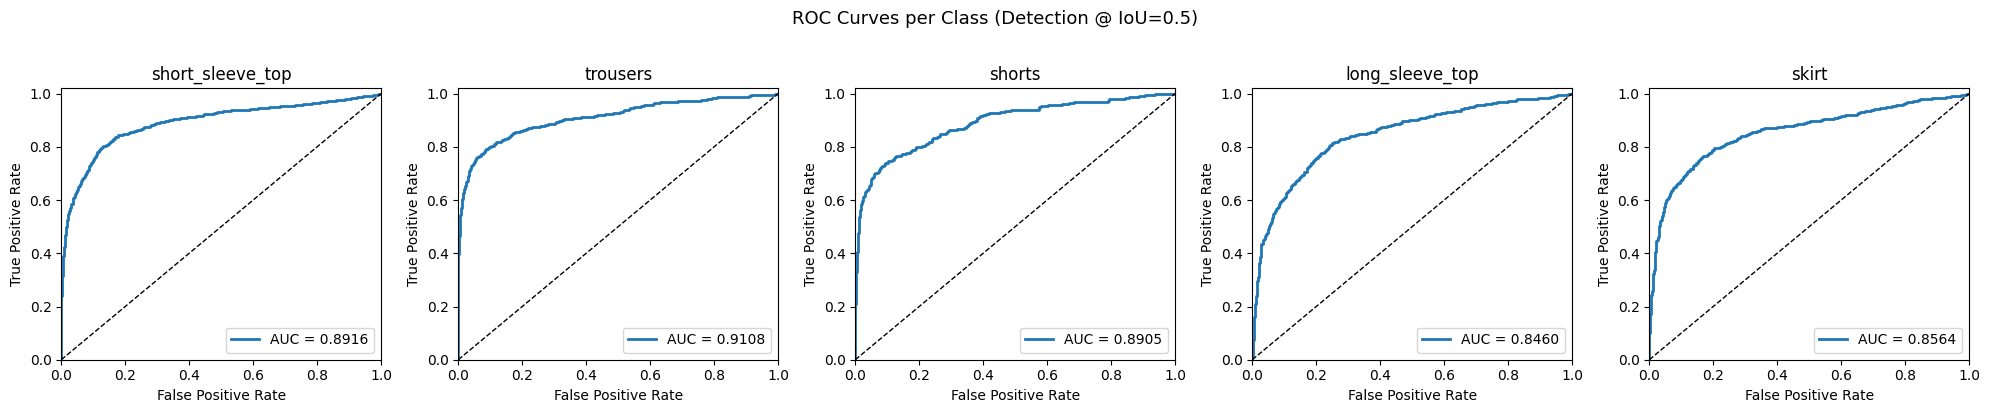

ROC curves saved to /kaggle/working/roc_curves_detection.png

F1-Score vs Confidence Threshold per class:
  short_sleeve_top        Best F1 = 0.8055  @ threshold = 0.66
  trousers                Best F1 = 0.8125  @ threshold = 0.82
  shorts                  Best F1 = 0.7135  @ threshold = 0.70
  long_sleeve_top         Best F1 = 0.6164  @ threshold = 0.77
  skirt                   Best F1 = 0.6816  @ threshold = 0.85


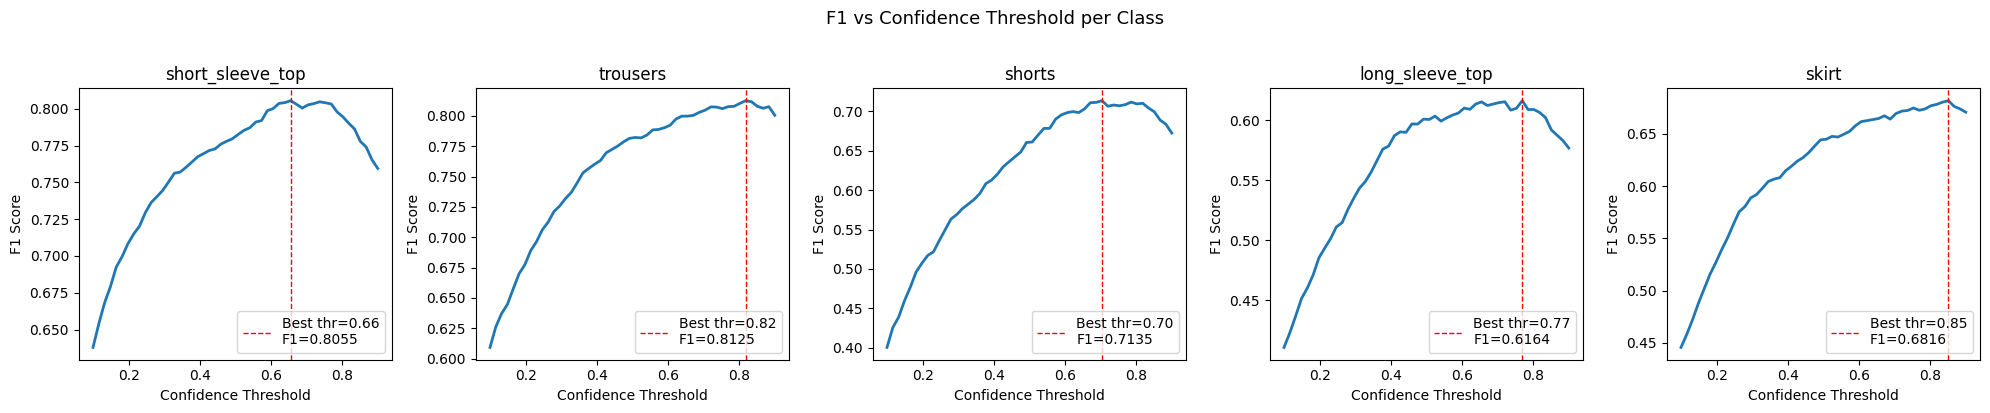

F1 curves saved to /kaggle/working/f1_threshold_curves.png


In [17]:
print("=" * 70)
print("DETECTION RESULTS  (IoU threshold = 0.5)")
print("=" * 70)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 70)
macro_precisions, macro_recalls, macro_f1s = [], [], []
for cls_id in range(1, NUM_CLASSES):
    tp = tp_det[cls_id]
    fp = fp_det[cls_id]
    fn = fn_det[cls_id]
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    macro_precisions.append(precision)
    macro_recalls.append(recall)
    macro_f1s.append(f1)
    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}")
print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(macro_precisions):>10.4f} "
      f"{np.mean(macro_recalls):>10.4f} {np.mean(macro_f1s):>10.4f}")
all_tp = sum(tp_det.values())
all_fp = sum(fp_det.values())
all_fn = sum(fn_det.values())
micro_p  = all_tp / (all_tp + all_fp + 1e-6)
micro_r  = all_tp / (all_tp + all_fn + 1e-6)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-6)
print(f"  {'Micro Average':<20} {micro_p:>10.4f} {micro_r:>10.4f} {micro_f1:>10.4f}")
print()
print("=" * 70)
print("SEGMENTATION RESULTS")
print("=" * 70)
print(f"{'Class':<22} {'mIoU':>10} {'Dice':>10} {'Instances':>10}")
print("-" * 70)
all_ious, all_dices = [], []
for cls_id in range(1, NUM_CLASSES):
    cnt = seg_count[cls_id]
    if cnt > 0:
        class_iou  = iou_sum_seg[cls_id]  / cnt
        class_dice = dice_sum_seg[cls_id] / cnt
    else:
        class_iou = class_dice = 0.0
    all_ious.append(class_iou)
    all_dices.append(class_dice)
    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {class_iou:>10.4f} {class_dice:>10.4f} {cnt:>10}")
print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(all_ious):>10.4f} {np.mean(all_dices):>10.4f}")
print("=" * 70)


# ══════════════════════════════════════════════════════════════════════════════
# mAP@[0.5:0.95]  +  ROC / AUC / F1
# ══════════════════════════════════════════════════════════════════════════════
from torchvision.ops import box_iou
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

IOU_THRESHOLDS = np.arange(0.5, 1.0, 0.05)  # 0.50, 0.55, ..., 0.95

# per_class_scores for ROC
per_class_scores = {i: {"scores": [], "matches": []} for i in range(1, NUM_CLASSES)}

# per_class_ap[cls_id][iou_idx] = list of APs across images
per_class_ap = {i: {j: [] for j in range(len(IOU_THRESHOLDS))} for i in range(1, NUM_CLASSES)}

model.eval()
print("Running mAP@[0.5:0.95] + ROC evaluation on validation set...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="mAP Eval"):

        images  = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]

            # ── ROC: collect scores + match label at IoU=0.5 ──────────────────
            for p_idx in range(len(pred_boxes)):
                p_cls   = pred_labels[p_idx].item()
                p_score = pred_scores[p_idx].item()

                if p_cls not in per_class_scores:
                    continue

                same_cls_gt = (gt_labels == p_cls).nonzero(as_tuple=True)[0]
                matched = 0
                if len(same_cls_gt) > 0:
                    iou_vals = box_iou(
                        pred_boxes[p_idx].unsqueeze(0),
                        gt_boxes[same_cls_gt]
                    )[0]
                    if iou_vals.max().item() >= 0.5:
                        matched = 1

                per_class_scores[p_cls]["scores"].append(p_score)
                per_class_scores[p_cls]["matches"].append(matched)

            # ── mAP: compute per-class AP at each IoU threshold ───────────────
            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            iou_matrix = box_iou(pred_boxes, gt_boxes)  # (P, G)

            for cls_id in range(1, NUM_CLASSES):

                # Filter predictions and GT to this class only
                pred_cls_mask = (pred_labels == cls_id)
                gt_cls_mask   = (gt_labels   == cls_id)

                cls_pred_boxes  = pred_boxes[pred_cls_mask]
                cls_pred_scores = pred_scores[pred_cls_mask]
                cls_gt_boxes    = gt_boxes[gt_cls_mask]

                n_gt = cls_gt_boxes.shape[0]

                if len(cls_pred_boxes) == 0 or n_gt == 0:
                    continue

                cls_iou_matrix = box_iou(cls_pred_boxes, cls_gt_boxes)  # (P_cls, G_cls)

                # Sort predictions by score descending
                order = cls_pred_scores.argsort(descending=True)

                for t_idx, iou_thresh in enumerate(IOU_THRESHOLDS):

                    gt_matched = torch.zeros(n_gt, dtype=torch.bool)
                    tp_list, fp_list = [], []

                    for p_idx in order:
                        iou_row  = cls_iou_matrix[p_idx]
                        best_iou, best_j = iou_row.max(0)

                        if best_iou >= iou_thresh and not gt_matched[best_j]:
                            tp_list.append(1)
                            fp_list.append(0)
                            gt_matched[best_j] = True
                        else:
                            tp_list.append(0)
                            fp_list.append(1)

                    tp_cum = np.cumsum(tp_list)
                    fp_cum = np.cumsum(fp_list)

                    recalls_curve    = tp_cum / (n_gt + 1e-6)
                    precisions_curve = tp_cum / (tp_cum + fp_cum + 1e-6)

                    # 11-point interpolated AP
                    ap = 0.0
                    for thr in np.linspace(0, 1, 11):
                        prec_at_rec = precisions_curve[recalls_curve >= thr]
                        ap += prec_at_rec.max() if len(prec_at_rec) > 0 else 0.0
                    ap /= 11.0

                    per_class_ap[cls_id][t_idx].append(ap)

# ── mAP table ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("mAP@[0.5:0.95]")
print("=" * 70)
print(f"{'Class':<25} {'AP@0.5':>10} {'AP@0.75':>10} {'mAP[.5:.95]':>12}")
print("-" * 70)

all_map = []
for cls_id in range(1, NUM_CLASSES):
    aps_per_thresh = per_class_ap[cls_id]

    ap50   = np.mean(aps_per_thresh[0])  if aps_per_thresh[0]  else 0.0
    ap75   = np.mean(aps_per_thresh[5])  if aps_per_thresh[5]  else 0.0
    mean_ap = np.mean([np.mean(v) if v else 0.0 for v in aps_per_thresh.values()])

    all_map.append(mean_ap)
    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<23} {ap50:>10.4f} {ap75:>10.4f} {mean_ap:>12.4f}")

print("-" * 70)
print(f"  {'Overall mAP':<23} {'':>10} {'':>10} {np.mean(all_map):>12.4f}")
print("=" * 70)
           



# ── ROC curves + AUC ──────────────────────────────────────────────────────────
print("\nROC AUC per class:")
print("-" * 40)

fig, axes = plt.subplots(1, NUM_CLASSES - 1, figsize=(4 * (NUM_CLASSES - 1), 4))
if NUM_CLASSES - 1 == 1:
    axes = [axes]

roc_aucs = {}
for idx, cls_id in enumerate(range(1, NUM_CLASSES)):
    scores  = per_class_scores[cls_id]["scores"]
    matches = per_class_scores[cls_id]["matches"]
    name    = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")

    if len(scores) == 0 or sum(matches) == 0:
        print(f"  {name:<22}  AUC = N/A (no positive predictions)")
        roc_aucs[cls_id] = None
        axes[idx].set_title(f"{name}\nAUC = N/A")
        axes[idx].axis("off")
        continue

    fpr, tpr, _ = roc_curve(matches, scores)
    roc_auc     = auc(fpr, tpr)
    roc_aucs[cls_id] = roc_auc

    print(f"  {name:<22}  AUC = {roc_auc:.4f}")

    axes[idx].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    axes[idx].plot([0, 1], [0, 1], "k--", lw=1)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.02])
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].set_title(f"{name}")
    axes[idx].legend(loc="lower right")

plt.suptitle("ROC Curves per Class (Detection @ IoU=0.5)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves_detection.png", bbox_inches="tight", dpi=150)
plt.show()
print("ROC curves saved to /kaggle/working/roc_curves_detection.png")

# ── F1 vs threshold curve ──────────────────────────────────────────────────────
print("\nF1-Score vs Confidence Threshold per class:")
fig2, axes2 = plt.subplots(1, NUM_CLASSES - 1, figsize=(4 * (NUM_CLASSES - 1), 4))
if NUM_CLASSES - 1 == 1:
    axes2 = [axes2]

for idx, cls_id in enumerate(range(1, NUM_CLASSES)):
    scores  = np.array(per_class_scores[cls_id]["scores"])
    matches = np.array(per_class_scores[cls_id]["matches"])
    name    = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")

    if len(scores) == 0:
        axes2[idx].set_title(f"{name}\nNo data")
        axes2[idx].axis("off")
        continue

    thresholds = np.linspace(0.1, 0.9, 50)
    f1_scores  = []

    for thr in thresholds:
        pred_pos = (scores >= thr).astype(int)
        tp = ((pred_pos == 1) & (matches == 1)).sum()
        fp = ((pred_pos == 1) & (matches == 0)).sum()
        fn = ((pred_pos == 0) & (matches == 1)).sum()
        p  = tp / (tp + fp + 1e-6)
        r  = tp / (tp + fn + 1e-6)
        f1 = 2 * p * r / (p + r + 1e-6)
        f1_scores.append(f1)

    best_thr = thresholds[np.argmax(f1_scores)]
    best_f1  = max(f1_scores)

    axes2[idx].plot(thresholds, f1_scores, lw=2)
    axes2[idx].axvline(best_thr, color="red", linestyle="--", lw=1,
                       label=f"Best thr={best_thr:.2f}\nF1={best_f1:.4f}")
    axes2[idx].set_xlabel("Confidence Threshold")
    axes2[idx].set_ylabel("F1 Score")
    axes2[idx].set_title(f"{name}")
    axes2[idx].legend(loc="lower right")
    print(f"  {name:<22}  Best F1 = {best_f1:.4f}  @ threshold = {best_thr:.2f}")

plt.suptitle("F1 vs Confidence Threshold per C0lass", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/f1_threshold_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("F1 curves saved to /kaggle/working/f1_threshold_curves.png")

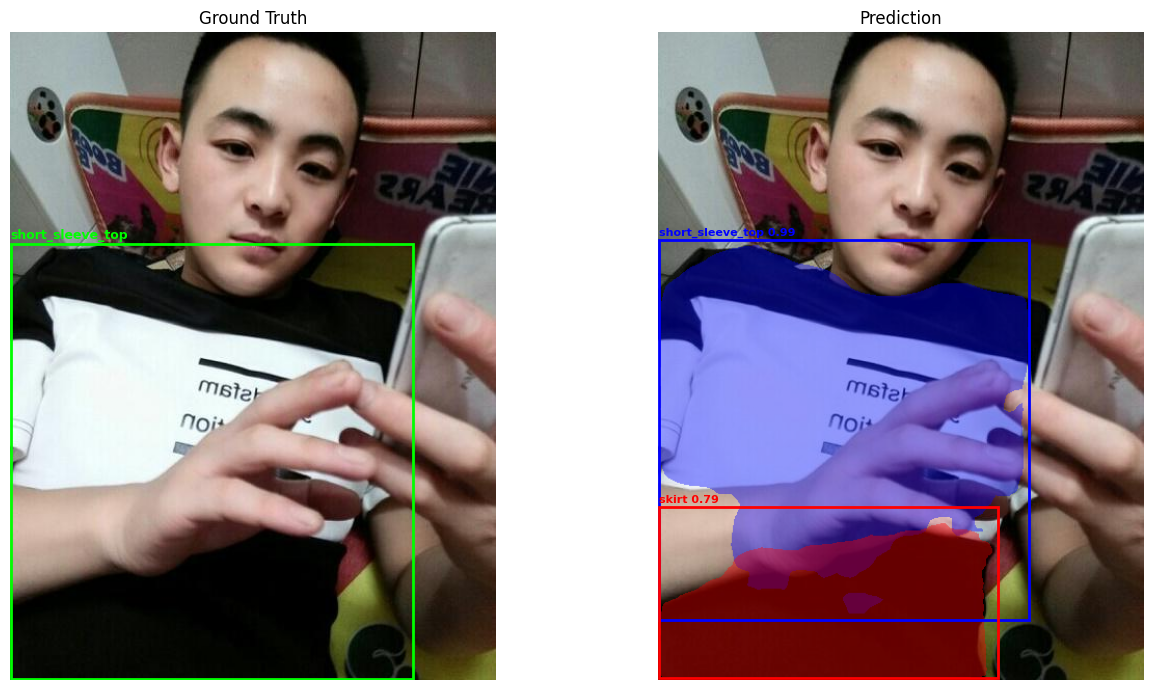

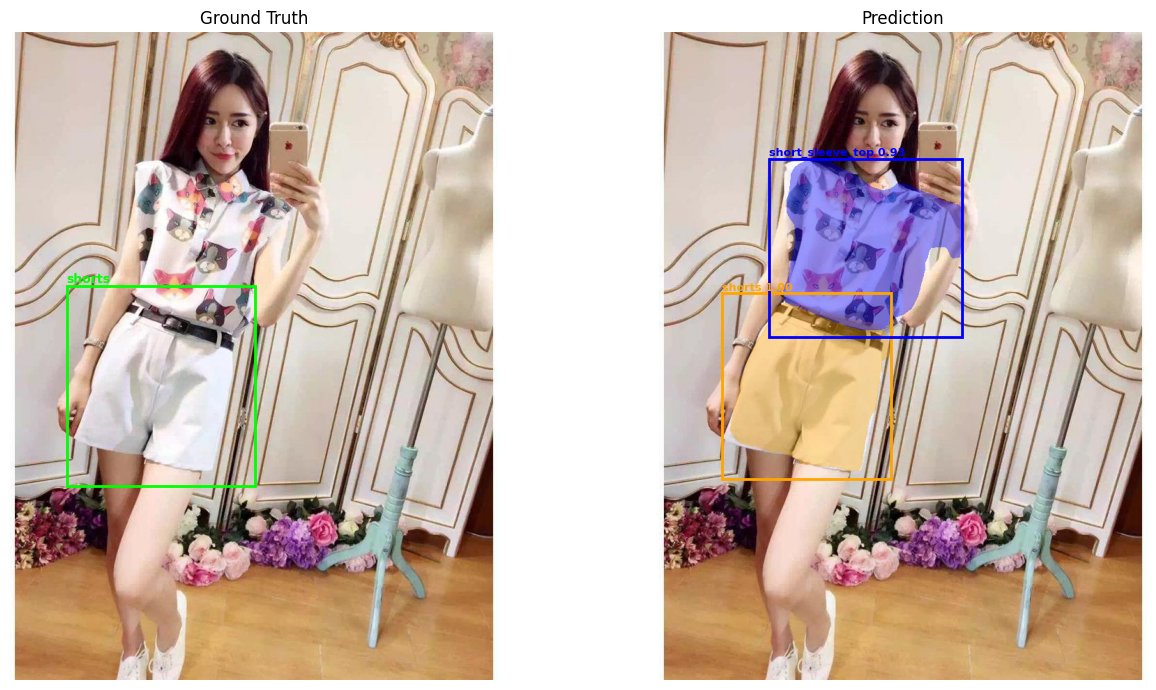

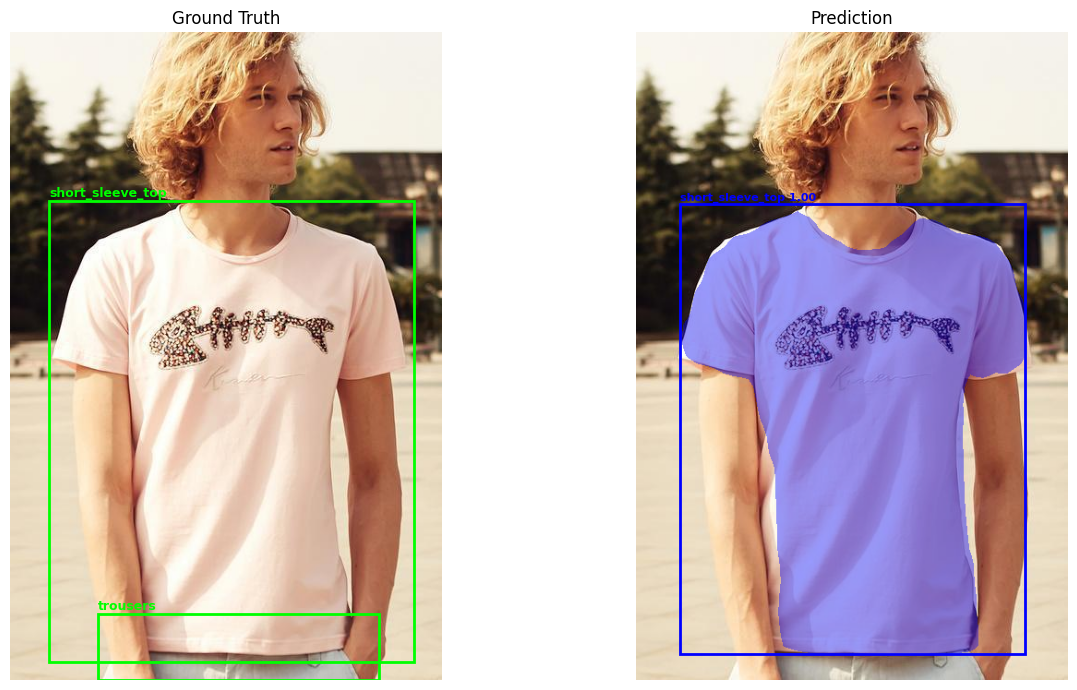

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import random

COLORS = ["red", "blue", "green", "orange", "purple"]

def visualize_prediction(model, dataset, idx=None, score_thresh=0.5):
    model.eval()
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_tensor, target = dataset[idx]
    image_np = img_tensor.permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]

    pred_boxes  = output["boxes"].cpu().numpy()
    pred_scores = output["scores"].cpu().numpy()
    pred_labels = output["labels"].cpu().numpy()
    pred_masks  = output["masks"].cpu().numpy()    # (N, 1, H, W)

    keep = pred_scores >= score_thresh
    pred_boxes  = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_masks  = pred_masks[keep]
    pred_scores = pred_scores[keep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Ground truth
    axes[0].imshow(image_np)
    axes[0].set_title("Ground Truth")
    for box, lbl in zip(target["boxes"].numpy(), target["labels"].numpy()):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 4, IDX_TO_NAME.get(lbl, str(lbl)),
                     color="lime", fontsize=9, fontweight="bold")
    axes[0].axis("off")

    # Predictions
    overlay = image_np.copy()
    axes[1].imshow(overlay)
    axes[1].set_title("Prediction")
    for i, (box, lbl, score, mask) in enumerate(
            zip(pred_boxes, pred_labels, pred_scores, pred_masks)):
        x1, y1, x2, y2 = box
        color = COLORS[lbl % len(COLORS)]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 4,
                     f"{IDX_TO_NAME.get(lbl, str(lbl))} {score:.2f}",
                     color=color, fontsize=8, fontweight="bold")

        # Overlay mask
        binary_mask = (mask[0] >= MASK_THRESH).astype(np.float32)
        rgba = np.zeros((*binary_mask.shape, 4))
        r, g, b, _ = to_rgba(color)
        rgba[..., 0] = r
        rgba[..., 1] = g
        rgba[..., 2] = b
        rgba[..., 3] = binary_mask * 0.4
        axes[1].imshow(rgba)

    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Visualize a few samples
for _ in range(3):
    visualize_prediction(model, val_dataset, score_thresh=0.5)

In [15]:
torch.save(model.state_dict(), "/kaggle/working/maskrcnn_final_scratch.pth")
print("Final model saved to /kaggle/working/maskrcnn_final_scratch.pth")
print("Best model (lowest train loss) saved to", SAVE_PATH)

Final model saved to /kaggle/working/maskrcnn_final_scratch.pth
Best model (lowest train loss) saved to /kaggle/working/best_maskrcnn.pth


Done

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
EPOCHS = 10
best_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Training phase ─────────────────────────────────────────────────────────
    model.train()
    total_loss      = 0
    total_cls_loss  = 0
    total_box_loss  = 0
    total_mask_loss = 0
    total_obj_loss  = 0
    total_rpn_loss  = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):

        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss      += loss.item()
        total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
        total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
        total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
        total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
        total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    n = len(train_loader)
    avg_loss      = total_loss      / n
    avg_cls_loss  = total_cls_loss  / n
    avg_box_loss  = total_box_loss  / n
    avg_mask_loss = total_mask_loss / n
    avg_obj_loss  = total_obj_loss  / n
    avg_rpn_loss  = total_rpn_loss  / n

    # ── Validation phase ────────────────────────────────────────────────────────
    model.train()   # Mask R-CNN needs train() mode to compute losses on val too
    val_total_loss      = 0
    val_total_cls_loss  = 0
    val_total_box_loss  = 0
    val_total_mask_loss = 0
    val_total_obj_loss  = 0
    val_total_rpn_loss  = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):

            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            val_total_loss      += sum(loss_dict.values()).item()
            val_total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
            val_total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
            val_total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
            val_total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
            val_total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    m = len(val_loader)
    val_avg_loss      = val_total_loss      / m
    val_avg_cls_loss  = val_total_cls_loss  / m
    val_avg_box_loss  = val_total_box_loss  / m
    val_avg_mask_loss = val_total_mask_loss / m
    val_avg_obj_loss  = val_total_obj_loss  / m
    val_avg_rpn_loss  = val_total_rpn_loss  / m

    # ── Print comparison ────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*65}")
    print(f"{'Loss':<25} {'Train':>10} {'Val':>10} {'Diff':>10}")
    print(f"{'-'*65}")
    print(f"{'Total Loss':<25} {avg_loss:>10.4f} {val_avg_loss:>10.4f} {val_avg_loss - avg_loss:>+10.4f}")
    print(f"{'Classifier Loss':<25} {avg_cls_loss:>10.4f} {val_avg_cls_loss:>10.4f} {val_avg_cls_loss - avg_cls_loss:>+10.4f}")
    print(f"{'Box Reg Loss':<25} {avg_box_loss:>10.4f} {val_avg_box_loss:>10.4f} {val_avg_box_loss - avg_box_loss:>+10.4f}")
    print(f"{'Mask Loss':<25} {avg_mask_loss:>10.4f} {val_avg_mask_loss:>10.4f} {val_avg_mask_loss - avg_mask_loss:>+10.4f}")
    print(f"{'Objectness Loss':<25} {avg_obj_loss:>10.4f} {val_avg_obj_loss:>10.4f} {val_avg_obj_loss - avg_obj_loss:>+10.4f}")
    print(f"{'RPN Box Loss':<25} {avg_rpn_loss:>10.4f} {val_avg_rpn_loss:>10.4f} {val_avg_rpn_loss - avg_rpn_loss:>+10.4f}")
    print(f"{'-'*65}")

    # Overfitting warning
    if val_avg_loss - avg_loss > 0.15:
        print("  ⚠️  Warning: possible overfitting (val >> train loss)")
    elif val_avg_loss < avg_loss:
        print("  ✅ Val loss lower than train loss — generalizing well")
    else:
        print("  ℹ️  Val loss close to train loss — healthy training")

    # ── Save best model (based on val loss) ────────────────────────────────────
    if val_avg_loss < best_loss:
        best_loss = val_avg_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print("  💾 Best model saved!")

print(f"\nTraining complete. Best Val Loss: {round(best_loss, 4)}")

In [ ]:
from torchvision.ops import box_iou

# ── Load best model for evaluation ────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Thresholds
DET_SCORE_THRESH = 0.5    # confidence threshold for detections
IOU_THRESH       = 0.5    # IoU threshold for a "match" in detection
MASK_THRESH      = 0.5    # sigmoid threshold to binarize predicted masks

# Per-class accumulators  (index 1..5 = clothing classes)
tp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fn_det  = {i: 0 for i in range(1, NUM_CLASSES)}

iou_sum_seg  = {i: 0.0 for i in range(1, NUM_CLASSES)}
dice_sum_seg = {i: 0.0 for i in range(1, NUM_CLASSES)}
seg_count    = {i: 0   for i in range(1, NUM_CLASSES)}

print("Running evaluation on validation set...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):

        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()     # (N, 1, H, W) — probabilities

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks  = tgt["masks"]             # (M, H, W) — binary uint8

            # Filter by score
            keep = pred_scores >= DET_SCORE_THRESH
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_masks  = pred_masks[keep]

            # ── Detection metric (TP / FP / FN per class) ─────────────────────
            gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)  # (P, G)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]             # (G,)

                    # Only consider GT of same class
                    same_cls = (gt_labels == p_cls).numpy()
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~torch.tensor(same_cls)] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched[best_j]:
                        tp_det[p_cls] = tp_det.get(p_cls, 0) + 1
                        gt_matched[best_j] = True
                    else:
                        fp_det[p_cls] = fp_det.get(p_cls, 0) + 1

            # Unmatched GT = false negatives
            for g_idx in range(len(gt_boxes)):
                if not gt_matched[g_idx]:
                    g_cls = gt_labels[g_idx].item()
                    fn_det[g_cls] = fn_det.get(g_cls, 0) + 1

            # ── Segmentation metric (mIoU, Dice per matched instance) ──────────
            gt_matched2 = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]
                    same_cls = (gt_labels == p_cls)
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~same_cls] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched2[best_j]:
                        gt_matched2[best_j] = True

                        # Binarize predicted mask
                        p_mask = (pred_masks[p_idx, 0] >= MASK_THRESH).numpy().astype(np.uint8)
                        g_mask = gt_masks[best_j].numpy().astype(np.uint8)

                        # Resize pred mask to match GT if needed
                        if p_mask.shape != g_mask.shape:
                            p_mask = cv2.resize(p_mask, (g_mask.shape[1], g_mask.shape[0]),
                                                interpolation=cv2.INTER_NEAREST)

                        intersection = np.logical_and(p_mask, g_mask).sum()
                        union        = np.logical_or(p_mask,  g_mask).sum()
                        p_sum        = p_mask.sum()
                        g_sum        = g_mask.sum()

                        iou_val  = intersection / (union + 1e-6)
                        dice_val = 2 * intersection / (p_sum + g_sum + 1e-6)

                        iou_sum_seg[p_cls]  += iou_val
                        dice_sum_seg[p_cls] += dice_val
                        seg_count[p_cls]    += 1

print("\nEvaluation complete.")

In [ ]:
print("=" * 70)
print("DETECTION RESULTS  (IoU threshold = 0.5)")
print("=" * 70)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 70)

macro_precisions, macro_recalls, macro_f1s = [], [], []

for cls_id in range(1, NUM_CLASSES):
    tp = tp_det[cls_id]
    fp = fp_det[cls_id]
    fn = fn_det[cls_id]

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    macro_precisions.append(precision)
    macro_recalls.append(recall)
    macro_f1s.append(f1)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(macro_precisions):>10.4f} "
      f"{np.mean(macro_recalls):>10.4f} {np.mean(macro_f1s):>10.4f}")

all_tp = sum(tp_det.values())
all_fp = sum(fp_det.values())
all_fn = sum(fn_det.values())
micro_p  = all_tp / (all_tp + all_fp + 1e-6)
micro_r  = all_tp / (all_tp + all_fn + 1e-6)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-6)
print(f"  {'Micro Average':<20} {micro_p:>10.4f} {micro_r:>10.4f} {micro_f1:>10.4f}")

print()
print("=" * 70)
print("SEGMENTATION RESULTS")
print("=" * 70)
print(f"{'Class':<22} {'mIoU':>10} {'Dice':>10} {'Instances':>10}")
print("-" * 70)

all_ious, all_dices = [], []

for cls_id in range(1, NUM_CLASSES):
    cnt = seg_count[cls_id]
    if cnt > 0:
        class_iou  = iou_sum_seg[cls_id]  / cnt
        class_dice = dice_sum_seg[cls_id] / cnt
    else:
        class_iou = class_dice = 0.0

    all_ious.append(class_iou)
    all_dices.append(class_dice)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {class_iou:>10.4f} {class_dice:>10.4f} {cnt:>10}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(all_ious):>10.4f} {np.mean(all_dices):>10.4f}")
print("=" * 70)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import random

COLORS = ["red", "blue", "green", "orange", "purple"]

def visualize_prediction(model, dataset, idx=None, score_thresh=0.5):
    model.eval()
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_tensor, target = dataset[idx]
    image_np = img_tensor.permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]

    pred_boxes  = output["boxes"].cpu().numpy()
    pred_scores = output["scores"].cpu().numpy()
    pred_labels = output["labels"].cpu().numpy()
    pred_masks  = output["masks"].cpu().numpy()    # (N, 1, H, W)

    keep = pred_scores >= score_thresh
    pred_boxes  = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_masks  = pred_masks[keep]
    pred_scores = pred_scores[keep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Ground truth
    axes[0].imshow(image_np)
    axes[0].set_title("Ground Truth")
    for box, lbl in zip(target["boxes"].numpy(), target["labels"].numpy()):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 4, IDX_TO_NAME.get(lbl, str(lbl)),
                     color="lime", fontsize=9, fontweight="bold")
    axes[0].axis("off")

    # Predictions
    overlay = image_np.copy()
    axes[1].imshow(overlay)
    axes[1].set_title("Prediction")
    for i, (box, lbl, score, mask) in enumerate(
            zip(pred_boxes, pred_labels, pred_scores, pred_masks)):
        x1, y1, x2, y2 = box
        color = COLORS[lbl % len(COLORS)]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 4,
                     f"{IDX_TO_NAME.get(lbl, str(lbl))} {score:.2f}",
                     color=color, fontsize=8, fontweight="bold")

        # Overlay mask
        binary_mask = (mask[0] >= MASK_THRESH).astype(np.float32)
        rgba = np.zeros((*binary_mask.shape, 4))
        r, g, b, _ = to_rgba(color)
        rgba[..., 0] = r
        rgba[..., 1] = g
        rgba[..., 2] = b
        rgba[..., 3] = binary_mask * 0.4
        axes[1].imshow(rgba)

    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Visualize a few samples
for _ in range(3):
    visualize_prediction(model, val_dataset, score_thresh=0.5)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/maskrcnn_final.pth")
print("Final model saved to /kaggle/working/maskrcnn_final.pth")
print("Best model (lowest train loss) saved to", SAVE_PATH)